<a href="https://colab.research.google.com/github/sajjkavinda/ML-based-Intrution-detection-system/blob/main/XGBoost_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

XGBoost Model Training

This notebook trains and evaluates an XGBoost classifier for binary network intrusion detection using the preprocessed CIC-IDS2018 dataset.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import libraries

In [2]:
import pickle
import joblib
import time
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

Set paths for the Dataset and Results

In [3]:
PROJECT_DIR = Path("/content/drive/MyDrive/MSc_Dissertation")

PROCESSED_DIR = PROJECT_DIR / "Dataset/Processed"

RESULTS_DIR = PROJECT_DIR / "Results"

MODEL_DIR = RESULTS_DIR / "Models"
METRICS_DIR = RESULTS_DIR / "Metrics"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

Load Train and Test data

In [4]:
with open(PROCESSED_DIR / "X_train.pkl", "rb") as f:
    X_train = pickle.load(f)

with open(PROCESSED_DIR / "X_test.pkl", "rb") as f:
    X_test = pickle.load(f)

with open(PROCESSED_DIR / "y_train.pkl", "rb") as f:
    y_train = pickle.load(f)

with open(PROCESSED_DIR / "y_test.pkl", "rb") as f:
    y_test = pickle.load(f)


print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (278560, 30)
Testing data: (69641, 30)


Train XGBoost Model

In [5]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)


start_time = time.time()


xgb.fit(
    X_train,
    y_train
)


training_time = time.time() - start_time


print(
    "Training time:",
    training_time,
    "seconds"
)

Training time: 7.14070200920105 seconds


Prediction

In [6]:
start_time = time.time()


y_pred = xgb.predict(
    X_test
)


prediction_time = time.time() - start_time


print(
    "Prediction time:",
    prediction_time,
    "seconds"
)

Prediction time: 0.14099383354187012 seconds


Evaluation

In [7]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)


print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.9999856406427249
Precision: 0.9999278811481321
Recall: 1.0
F1-score: 0.999963939273737


Classification report

In [8]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55776
           1       1.00      1.00      1.00     13865

    accuracy                           1.00     69641
   macro avg       1.00      1.00      1.00     69641
weighted avg       1.00      1.00      1.00     69641



Confusion matrix

[[55775     1]
 [    0 13865]]


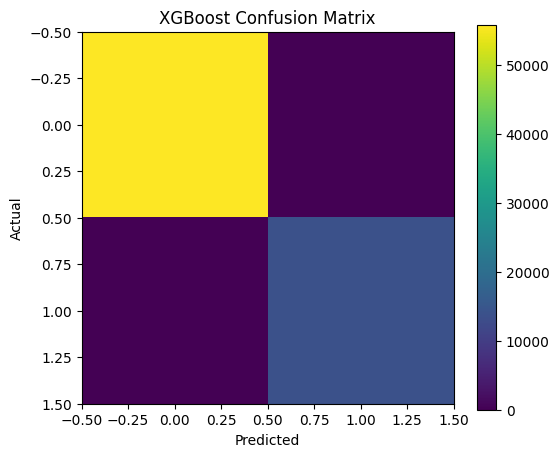

In [9]:
cm = confusion_matrix(
    y_test,
    y_pred
)


print(cm)

plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.show()

Feature importance

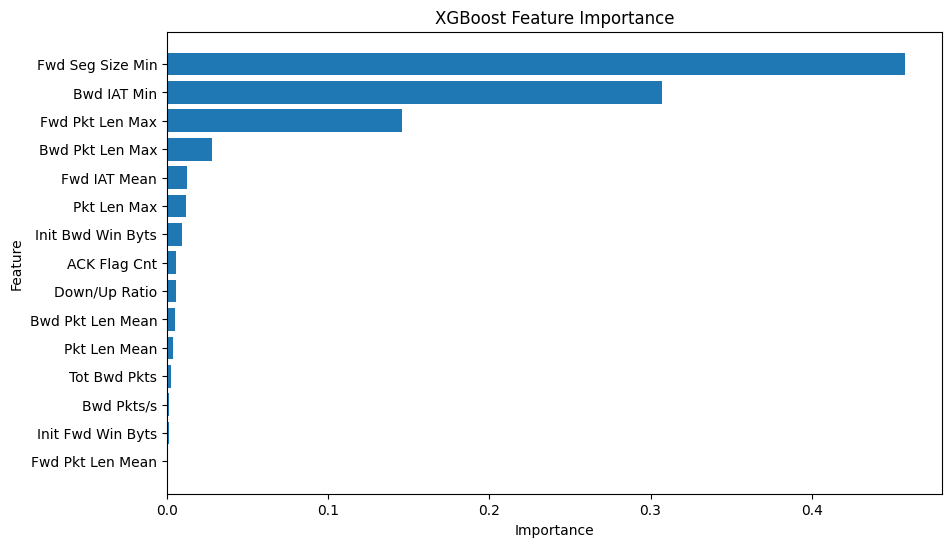

In [10]:
feature_importance = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "Importance": xgb.feature_importances_
    }
)


feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


feature_importance.head(20)

top_features = feature_importance.head(15)


plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title(
    "XGBoost Feature Importance"
)

plt.gca().invert_yaxis()

plt.show()

Save the model

In [11]:
MODEL_PATH = MODEL_DIR / "xgboost_model.pkl"


joblib.dump(
    xgb,
    MODEL_PATH
)


print("Model saved:")
print(MODEL_PATH)

Model saved:
/content/drive/MyDrive/MSc_Dissertation/Results/Models/xgboost_model.pkl


Save the results

In [12]:
results = pd.DataFrame(
    {
        "Model": ["XGBoost"],
        "Accuracy": [accuracy],
        "Precision": [precision],
        "Recall": [recall],
        "F1-score": [f1],
        "Training Time (seconds)": [training_time],
        "Prediction Time (seconds)": [prediction_time]
    }
)


RESULT_PATH = MODEL_DIR / "xgboost_results.csv"


results.to_csv(
    RESULT_PATH,
    index=False
)


print("Results saved:")
print(RESULT_PATH)


results

Results saved:
/content/drive/MyDrive/MSc_Dissertation/Results/Models/xgboost_results.csv


,Model,Accuracy,Precision,Recall,F1-score,Training Time (seconds),Prediction Time (seconds)
0,XGBoost,0.999986,0.999928,1.0,0.999964,7.140702,0.140994
